In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import gpt_model

import numba as nb

In [3]:
horizonts_years = [0.5, 1, 2, 3]
metrics = {}
controls = {}
deltas = {}
metrics['value'], controls['value'] = gpt_model.get_optimal_policy()
for h in horizonts_years:
    h_int = int(h / gpt_model.P.dt)
    metrics[f'capital_{h}'], controls[f'capital_{h}'] = gpt_model.get_optimal_policy_capital(h_int)
for k, v in metrics.items():
    deltas[k] = np.gradient(v, gpt_model.R_GRID, axis=1)

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

In [4]:
from matplotlib import pyplot as plt

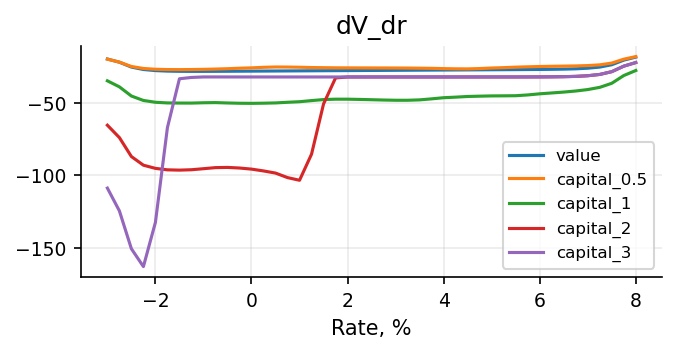

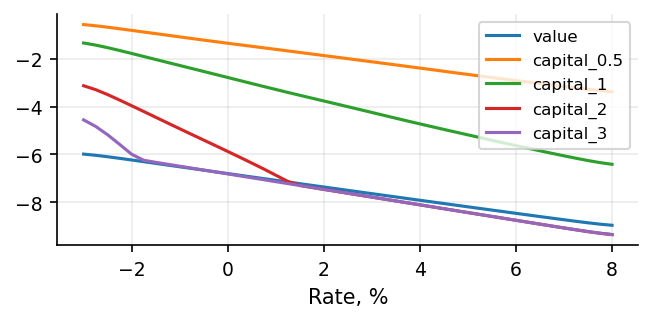

In [5]:
plt.figure(figsize=(5,2))
plt.title("dV_dr")
for k, v in deltas.items():
    plt.plot(100 * gpt_model.R_GRID, v[0, :, 20, 16], label=k)
plt.legend()
plt.xlabel("Rate, %")
plt.show()

plt.figure(figsize=(5,2))
for k, v in metrics.items():
    plt.plot(100 * gpt_model.R_GRID, v[0, :, 20, 16], label=k)
plt.legend()
plt.xlabel("Rate, %")
plt.show()

In [6]:
controls['zero'] = np.zeros_like(controls['value'])

In [7]:
values = {}

for k, control in controls.items():
    values[k] = gpt_model.get_value(control)

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

In [8]:
ix = np.argmin(np.abs(gpt_model.P.rbar - gpt_model.R_GRID))
iy = np.argmin(np.abs(gpt_model.P.q0 - gpt_model.Q_GRID))
iz = np.argmin(np.abs(gpt_model.P.K0 - gpt_model.K_GRID))

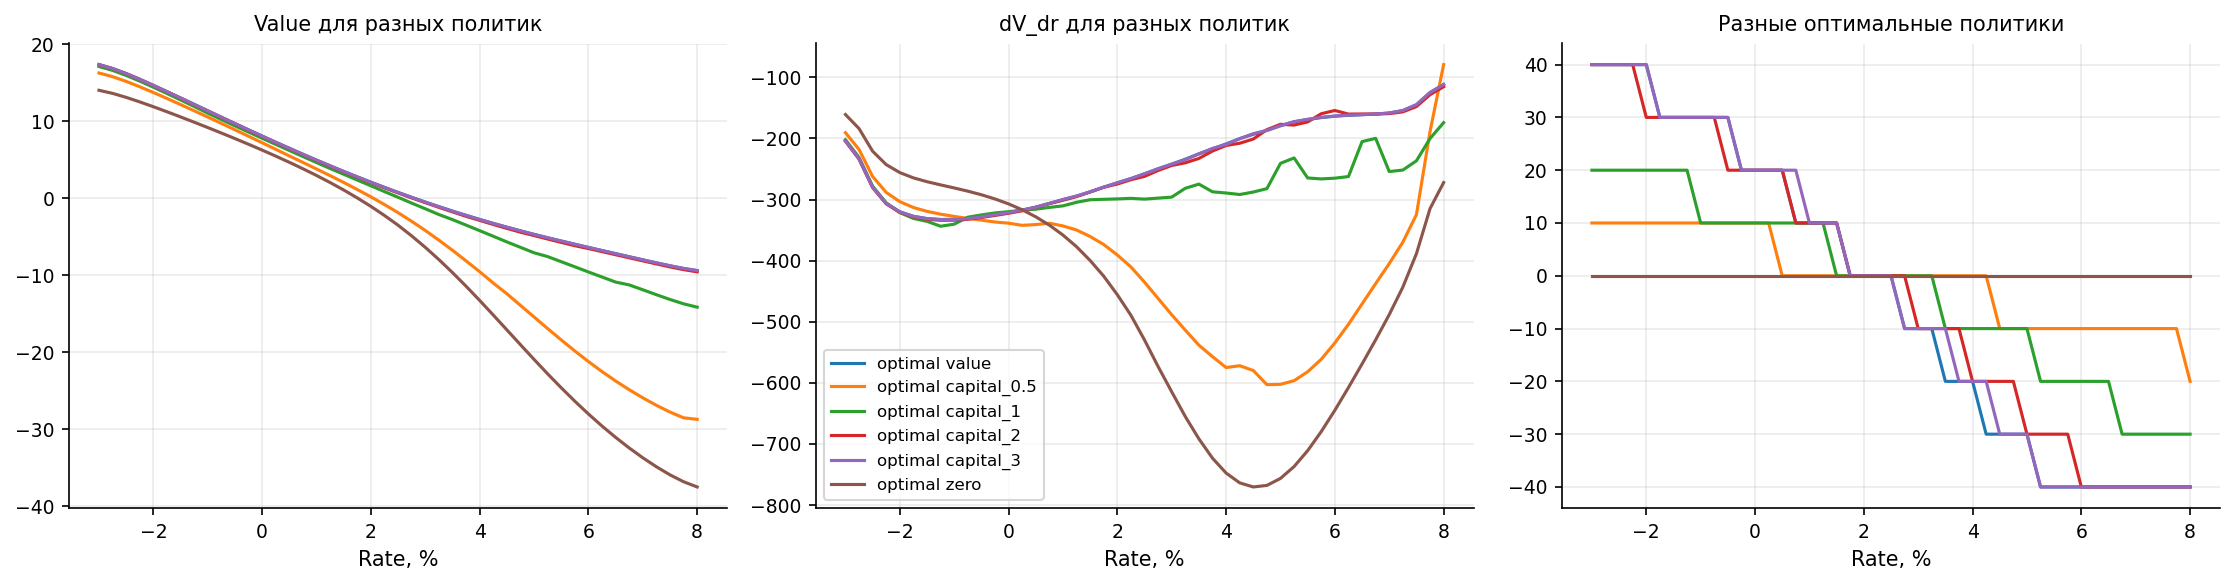

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].set_title("Value для разных политик", fontsize=10)
for k, v in values.items():
    ax[0].plot(100 * gpt_model.R_GRID, v[0, :, iy, iz],label=k)
ax[0].set_xlabel("Rate, %")
ax[1].set_xlabel("Rate, %")
ax[2].set_xlabel("Rate, %")

ax[1].set_title("dV_dr для разных политик", fontsize=10)
for k, v in values.items():
    dv_dr = np.gradient(v, gpt_model.R_GRID, axis=1)
    ax[1].plot(100 * gpt_model.R_GRID, dv_dr[0, :, iy, iz],label=f"optimal {k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, u in controls.items():
    ax[2].plot(100 * gpt_model.R_GRID, u[0, :, iy, iz],label=k)
fig.tight_layout()
plt.show()

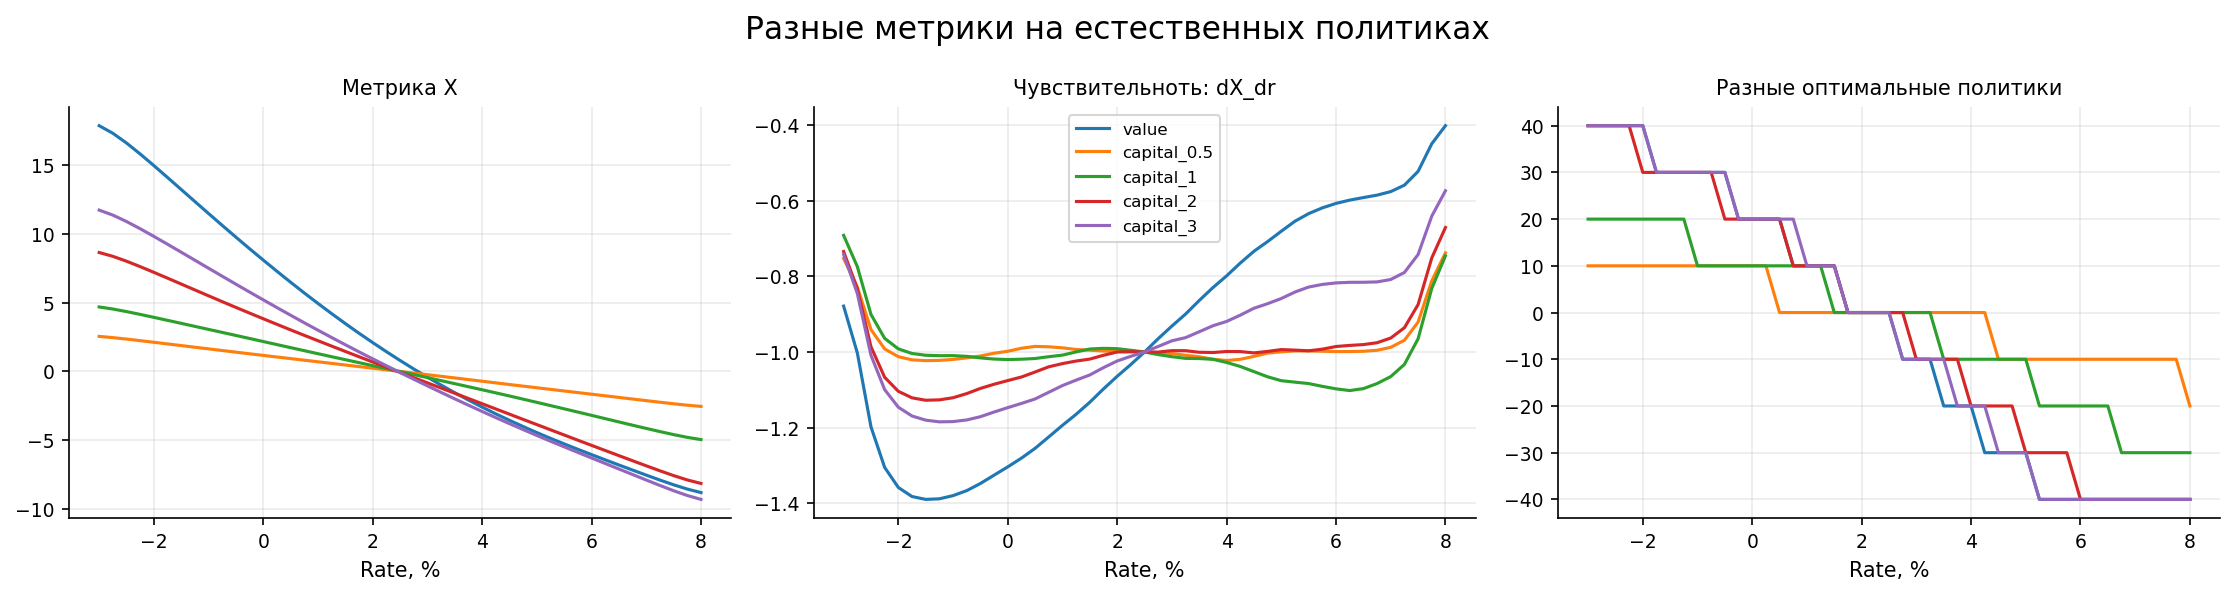

In [40]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plt.suptitle("Разные метрики на естественных политиках", fontsize=15)
ax[0].set_title("Метрика X", fontsize=10)
for k, v in metrics.items():
    ax[0].plot(100 * gpt_model.R_GRID, v[0, :, iy, iz],label=k)
ax[0].set_xlabel("Rate, %")
ax[1].set_xlabel("Rate, %")
ax[2].set_xlabel("Rate, %")

ax[1].set_title("Чувствительноть: dX_dr", fontsize=10)
scale = None
for k, v in metrics.items():
    dv_dr = np.gradient(v, gpt_model.R_GRID, axis=1)
    scale = np.abs(dv_dr[0, ix, iy, iz])
    ax[1].plot(100 * gpt_model.R_GRID, dv_dr[0, :, iy, iz] / scale,label=f"{k}")
ax[1].legend()

ax[2].set_title("Разные оптимальные политики", fontsize=10)
for k, v in metrics.items():
    ax[2].plot(100 * gpt_model.R_GRID, controls[k][0, :, iy, iz],label=k)
fig.tight_layout()
plt.show()

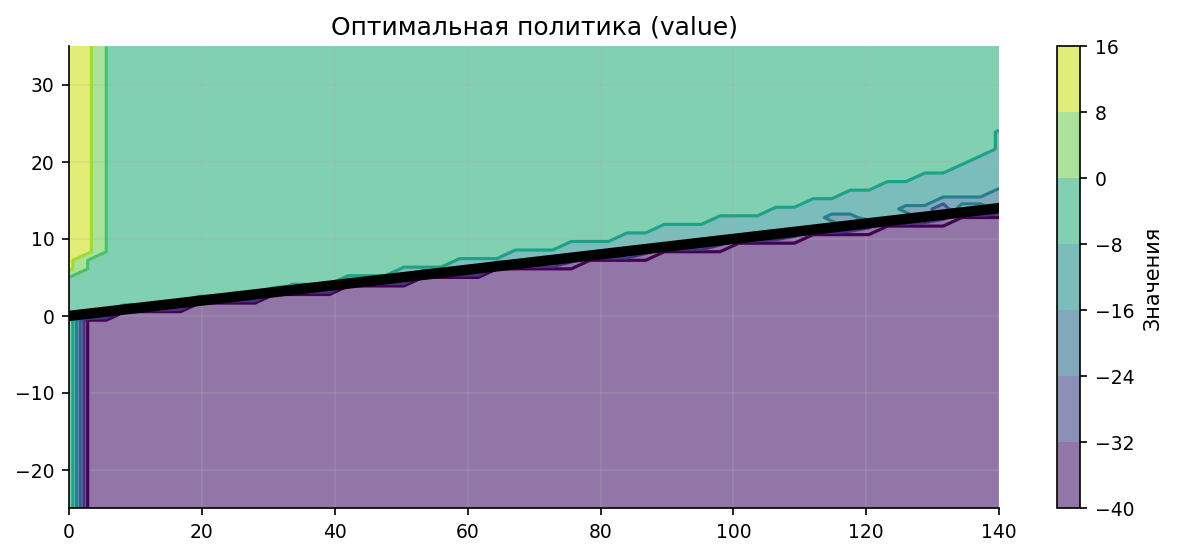

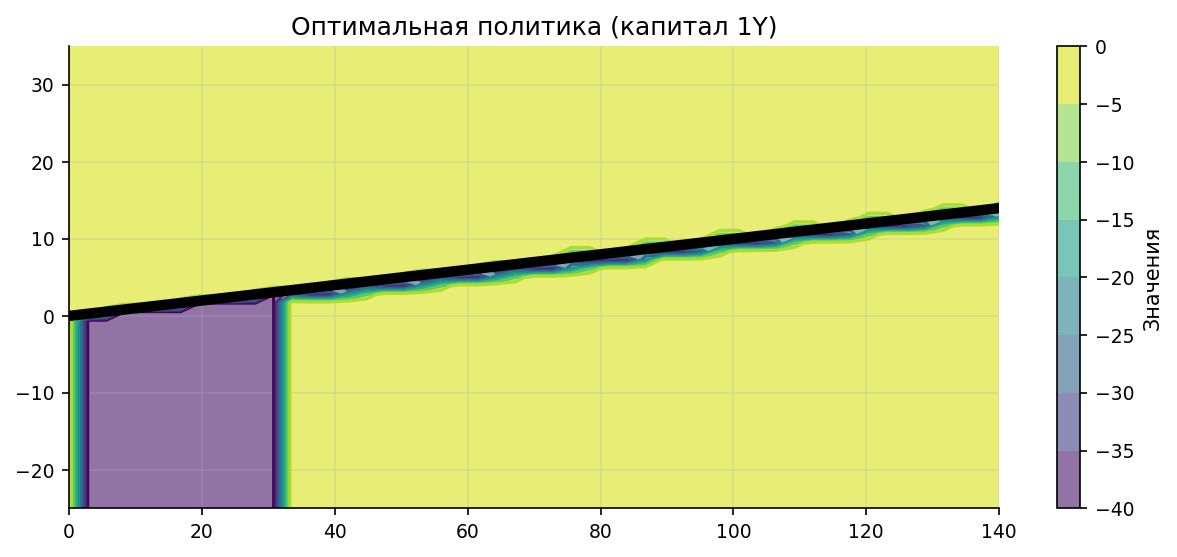

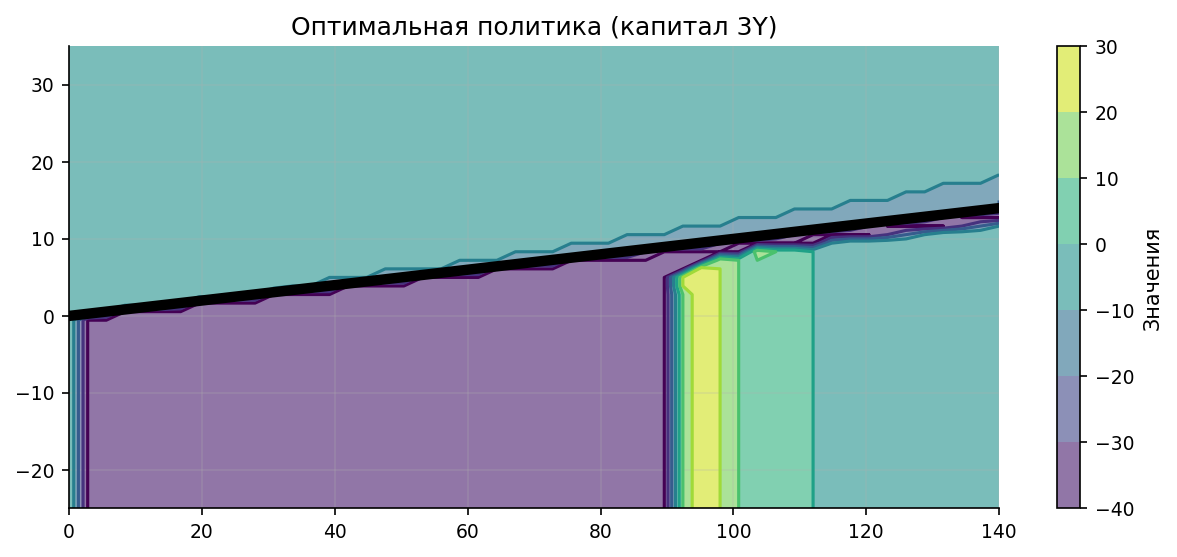

In [43]:
control = controls['value'][0]
plt.figure(figsize=(10, 4))
plt.title("Оптимальная политика (value)")
cf = plt.contourf(gpt_model.Q_GRID, gpt_model.K_GRID, control[ix].T, alpha=0.6)
plt.contour(gpt_model.Q_GRID, gpt_model.K_GRID, control[ix].T)
plt.plot(gpt_model.Q_GRID, gpt_model.Q_GRID * gpt_model.P.CAR, color='black', lw=5)
plt.colorbar(cf, label='Значения')
plt.show()

control = controls['capital_1'][0]
plt.figure(figsize=(10, 4))
plt.title("Оптимальная политика (капитал 1Y)")
cf = plt.contourf(gpt_model.Q_GRID, gpt_model.K_GRID, control[ix].T, alpha=0.6)
plt.contour(gpt_model.Q_GRID, gpt_model.K_GRID, control[ix].T)
plt.plot(gpt_model.Q_GRID, gpt_model.Q_GRID * gpt_model.P.CAR, color='black', lw=5)
plt.colorbar(cf, label='Значения')
plt.show()

control = controls['capital_3'][0]
plt.figure(figsize=(10, 4))
plt.title("Оптимальная политика (капитал 3Y)")
cf = plt.contourf(gpt_model.Q_GRID, gpt_model.K_GRID, control[ix].T, alpha=0.6)
plt.contour(gpt_model.Q_GRID, gpt_model.K_GRID, control[ix].T)
plt.plot(gpt_model.Q_GRID, gpt_model.Q_GRID * gpt_model.P.CAR, color='black', lw=5)
plt.colorbar(cf, label='Значения')
plt.show()

In [90]:
nt = gpt_model.P.N
np.random.seed(42)
shocks = np.random.randn(nt)
shocks = shocks - shocks.mean()

rate = np.zeros(nt + 1)
rate[0] = gpt_model.P.rbar
for t in range(nt):
    rate[t + 1] = gpt_model.P.rbar + gpt_model.PHI * (rate[t] - gpt_model.P.rbar) + gpt_model.BASE_SD * shocks[t]
    
scen = gpt_model.get_scenario(rate, gpt_model.P.q0, gpt_model.P.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])

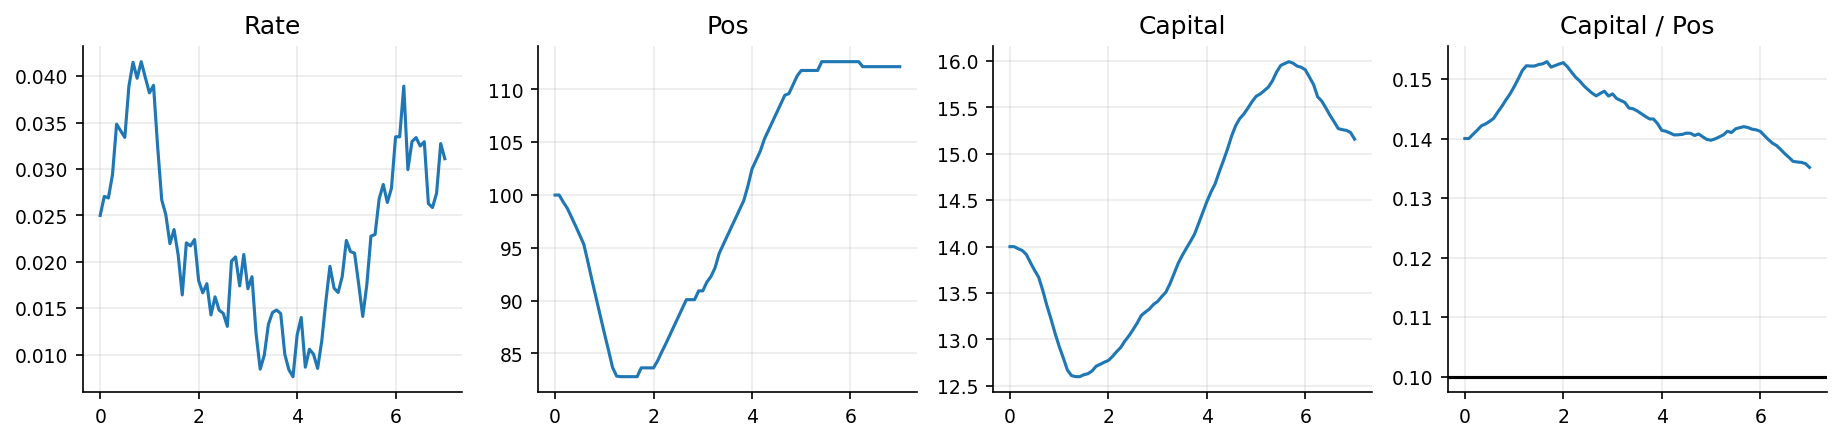

In [114]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(gpt_model.P.CAR, color='black')
plt.show()

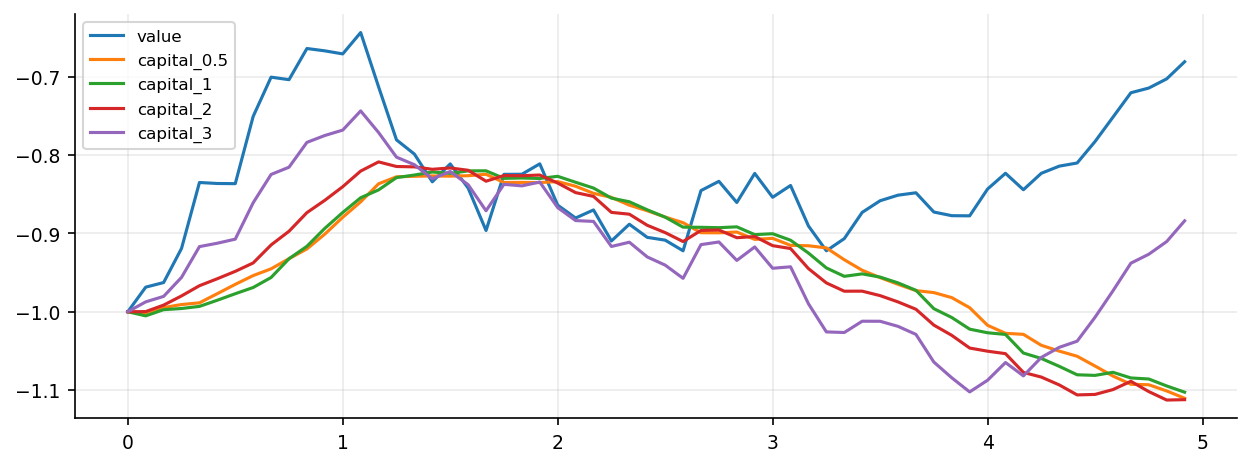

In [115]:
timegrid = np.arange(nt + 1) * gpt_model.P.dt
plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

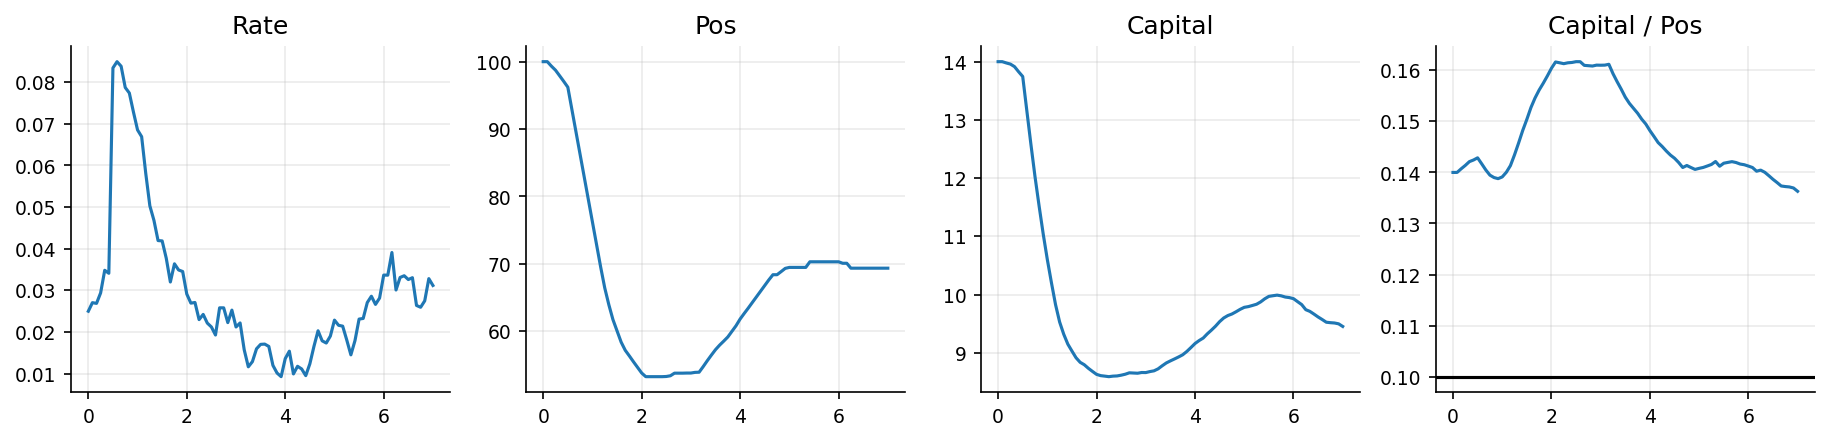

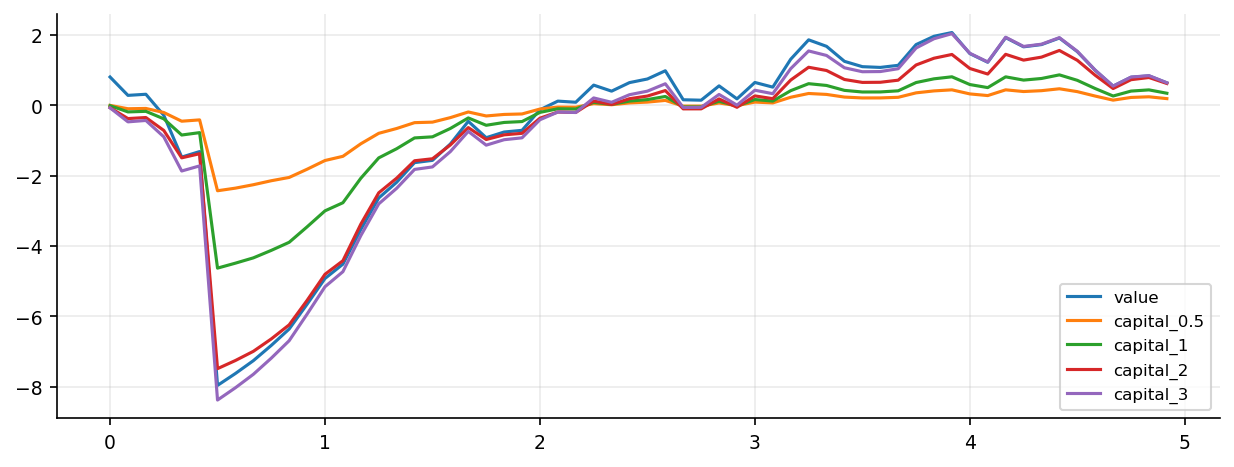

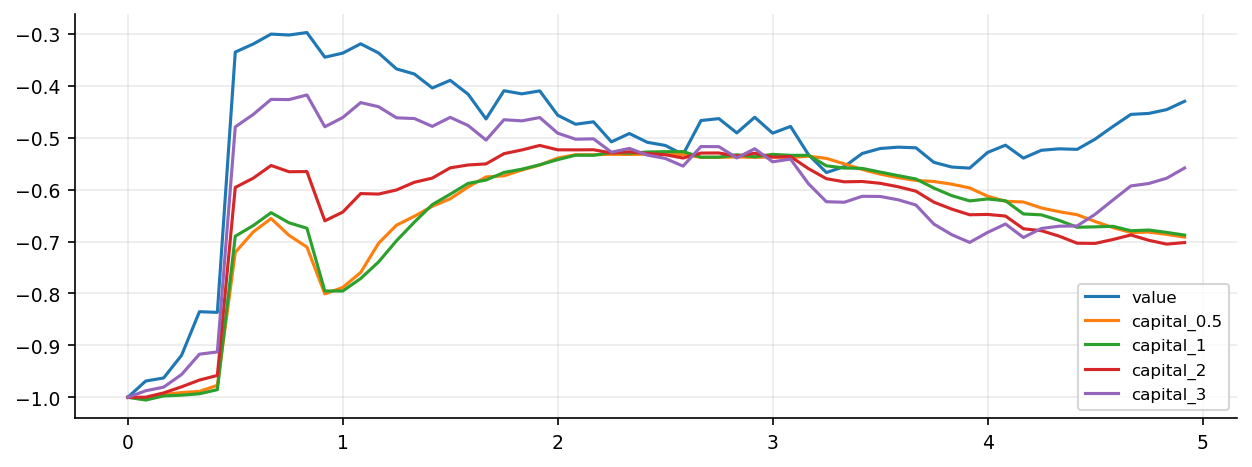

In [137]:
jump_phi = np.exp(-1.0 * gpt_model.P.dt)

jump_size = 0.05
jump_index = 5

jump_traj = np.zeros(nt + 1)
for t in range(nt):
    jump_traj[t + 1] = jump_traj[t] * jump_phi + jump_size * (jump_index == t)
    
    
scen = gpt_model.get_scenario((rate + jump_traj), gpt_model.P.q0, gpt_model.P.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
metrics_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    metrics_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])
        metrics_scen[k][t] = gpt_model.interp3_uniform(metrics[k][t], *scen_vec[t])
        
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(gpt_model.P.CAR, color='black')
plt.show()

timegrid = np.arange(nt + 1) * gpt_model.P.dt
plt.figure(figsize=(10, 3.5))
for k, d in metrics_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask], label=k)
plt.legend()
plt.show()

timegrid = np.arange(nt + 1) * gpt_model.P.dt
plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

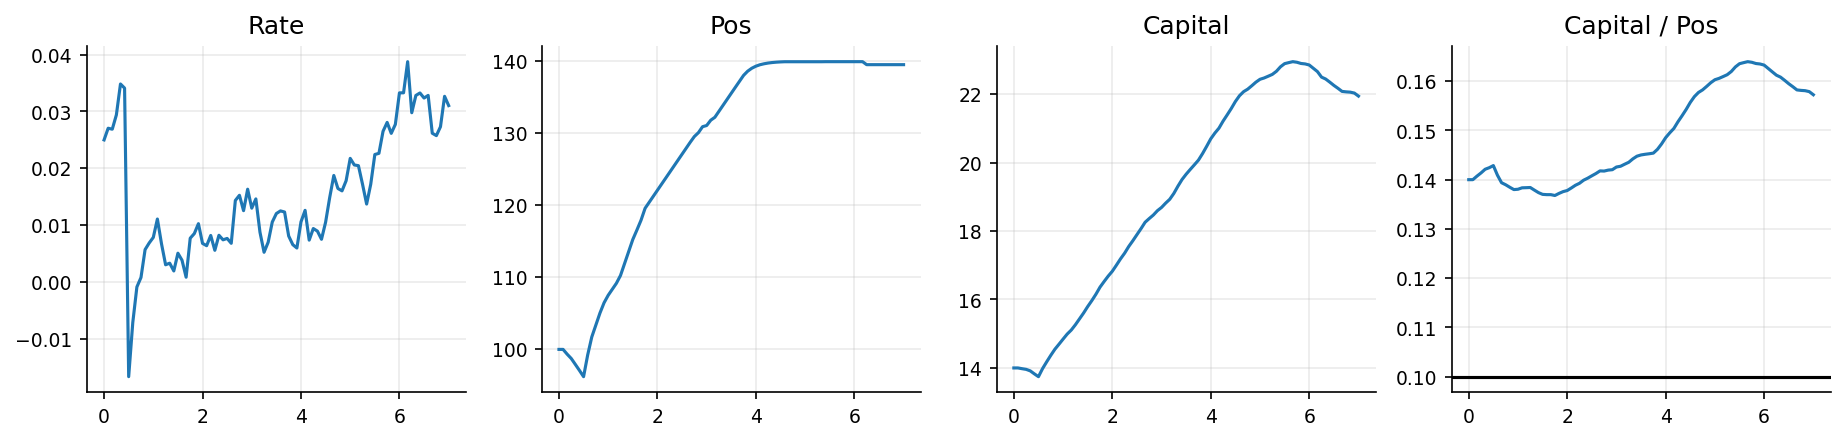

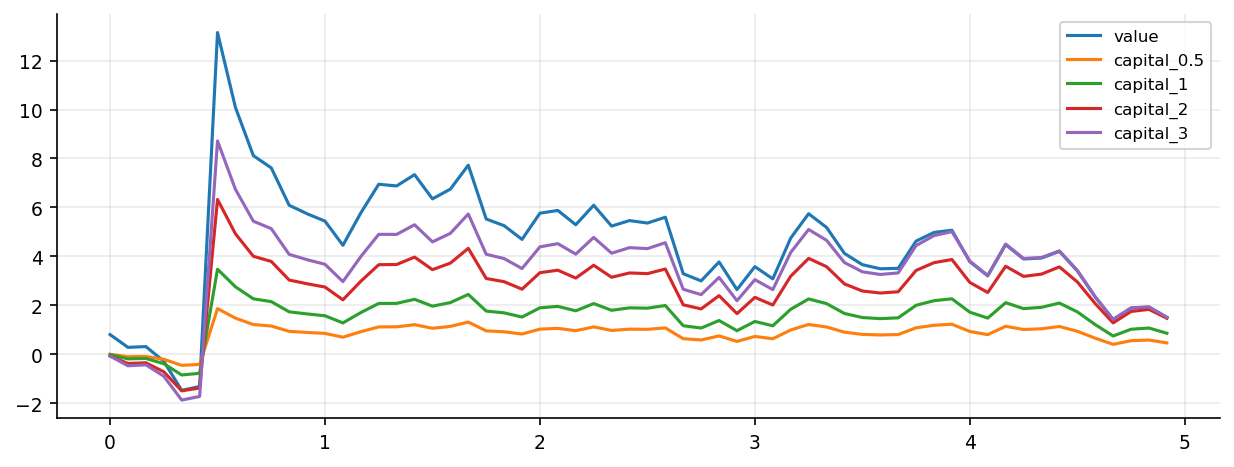

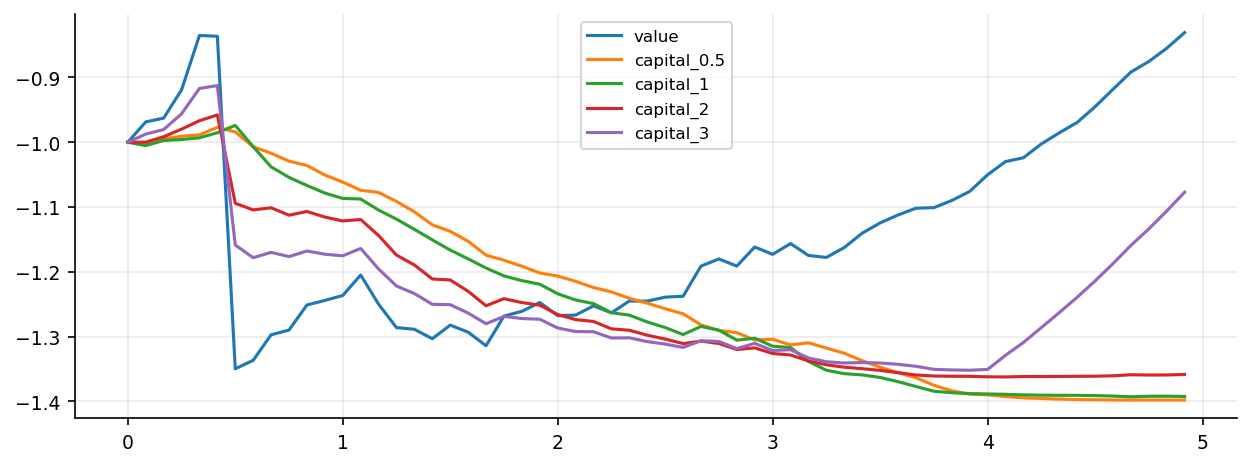

In [138]:
jump_size = -0.05
jump_traj = np.zeros(nt + 1)
for t in range(nt):
    jump_traj[t + 1] = jump_traj[t] * jump_phi + jump_size * (jump_index == t)
    
scen = gpt_model.get_scenario((rate + jump_traj), gpt_model.P.q0, gpt_model.P.K0, controls['value'])
scen_vec = np.stack([scen['rate'], scen['q'], scen['K']], axis=1)

deltas_scen = {}
metrics_scen = {}
for k, d in deltas.items():
    deltas_scen[k] = np.zeros(nt + 1)
    metrics_scen[k] = np.zeros(nt + 1)
    for t in range(nt + 1):
        deltas_scen[k][t] = gpt_model.interp3_uniform(d[t], *scen_vec[t])
        metrics_scen[k][t] = gpt_model.interp3_uniform(metrics[k][t], *scen_vec[t])
        
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
titles=['Rate', 'Pos', 'Capital']
for i in range(3):
    ax[i].set_title(titles[i])
    ax[i].plot(timegrid, scen_vec[:, i])
ax[3].plot(timegrid, scen_vec[:, 2] / scen_vec[:, 1])
ax[3].set_title("Capital / Pos")
ax[3].axhline(gpt_model.P.CAR, color='black')
plt.show()

timegrid = np.arange(nt + 1) * gpt_model.P.dt
plt.figure(figsize=(10, 3.5))
for k, d in metrics_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask], label=k)
plt.legend()
plt.show()

timegrid = np.arange(nt + 1) * gpt_model.P.dt
plt.figure(figsize=(10, 3.5))
for k, d in deltas_scen.items():
    mask = timegrid < 5
    plt.plot(timegrid[mask], d[mask] / np.abs(d[0]), label=k)
plt.legend()
plt.show()

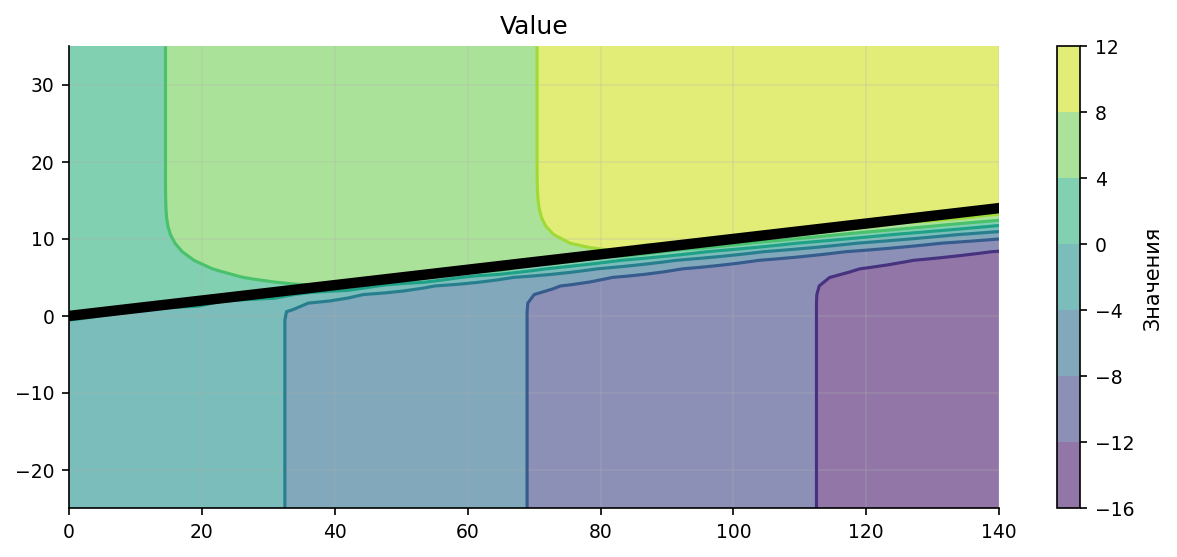

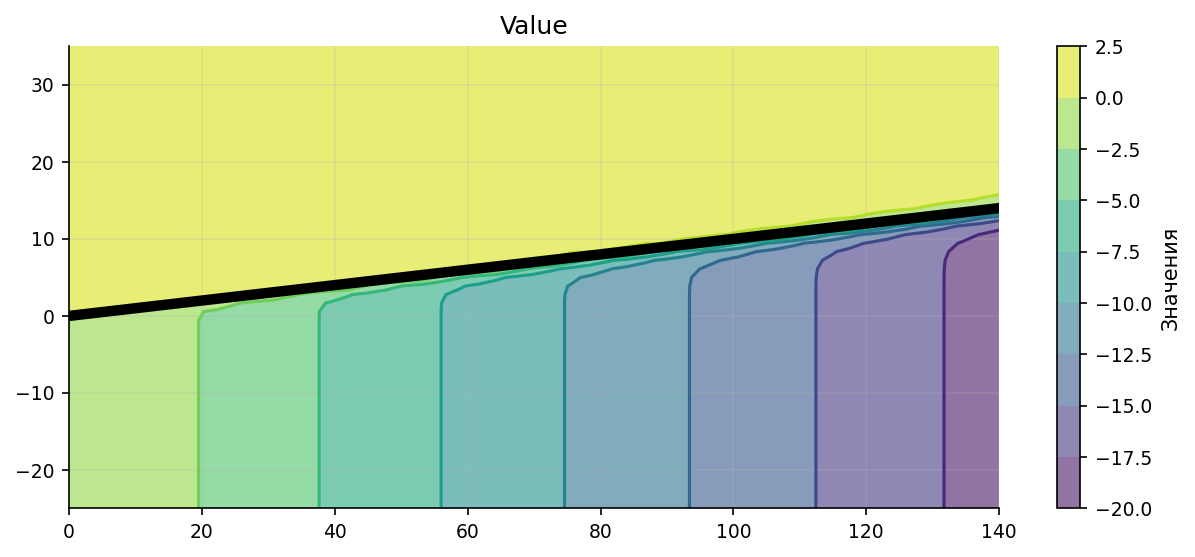

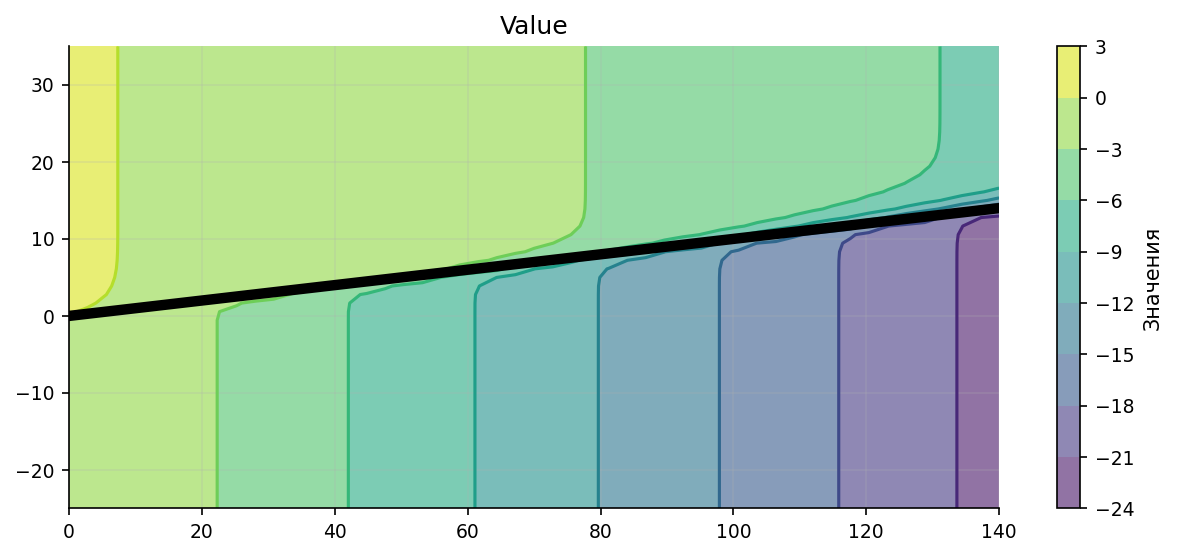

In [175]:
value = metrics['value'][0]
for rate_index in [10, 22, 32]:
    plt.figure(figsize=(10, 4))
    plt.title("Value")
    cf = plt.contourf(gpt_model.Q_GRID, gpt_model.K_GRID, value[rate_index].T, alpha=0.6)
    plt.contour(gpt_model.Q_GRID, gpt_model.K_GRID, value[rate_index].T)
    plt.plot(gpt_model.Q_GRID, gpt_model.Q_GRID * gpt_model.P.CAR, color='black', lw=5)
    plt.colorbar(cf, label='Значения')
    plt.show()

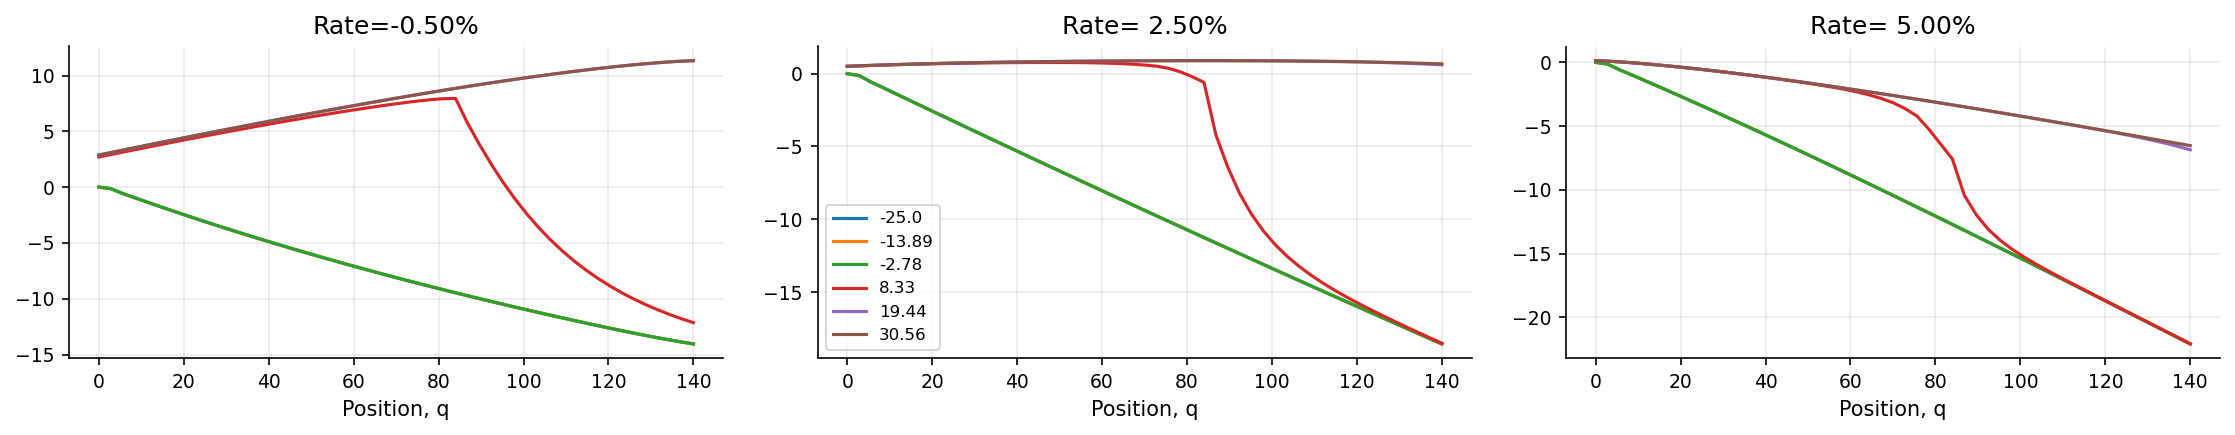

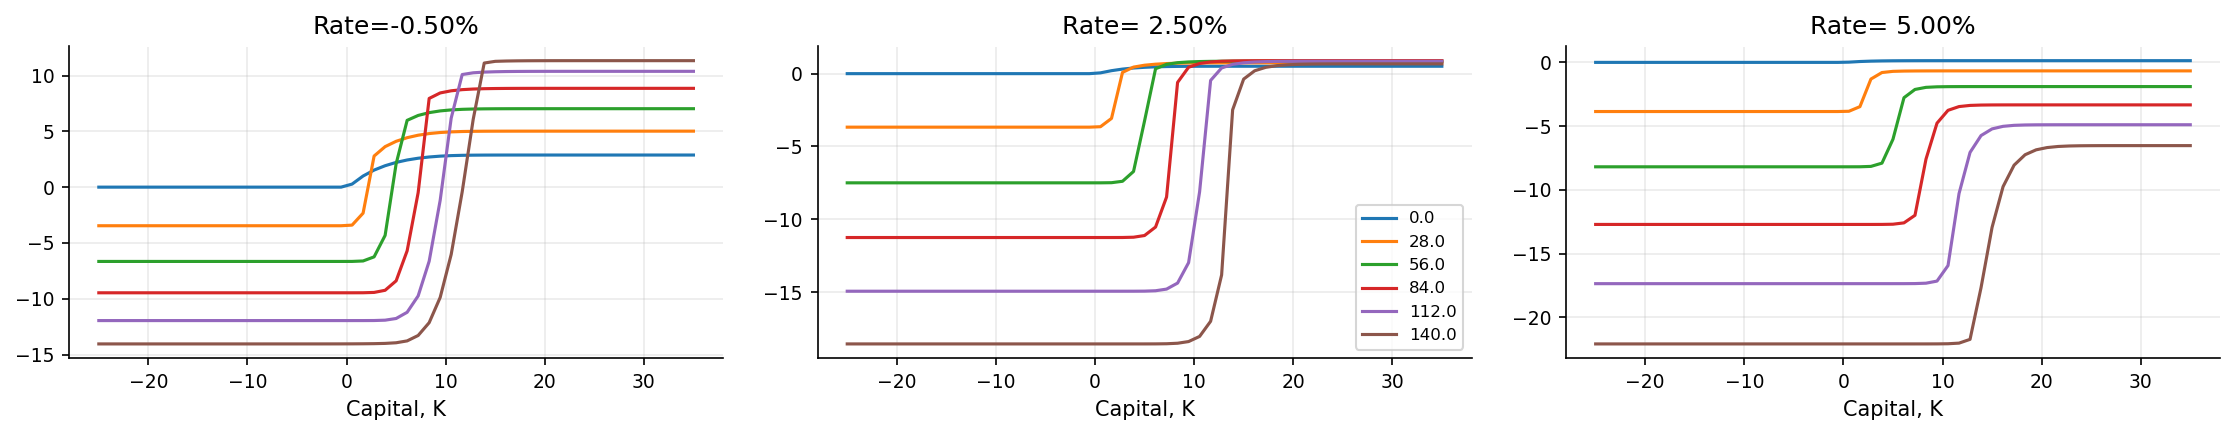

In [176]:
value = metrics['value'][0]
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
for i, rate_index in enumerate([10, 22, 32]):
    ax[i].set_title(f"Rate={100* gpt_model.R_GRID[rate_index] : 0.2f}%")
    ax[i].plot(gpt_model.Q_GRID, value[rate_index, :, ::10])
    ax[i].set_xlabel("Position, q")
ax[1].legend(gpt_model.K_GRID[::10].round(2))
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
for i, rate_index in enumerate([10, 22, 32]):
    ax[i].set_title(f"Rate={100* gpt_model.R_GRID[rate_index] : 0.2f}%")
    ax[i].plot(gpt_model.K_GRID, value[rate_index,  ::10].T)
    ax[i].set_xlabel("Capital, K")
ax[1].legend(gpt_model.Q_GRID[::10].round(2))
fig.tight_layout()
plt.show()

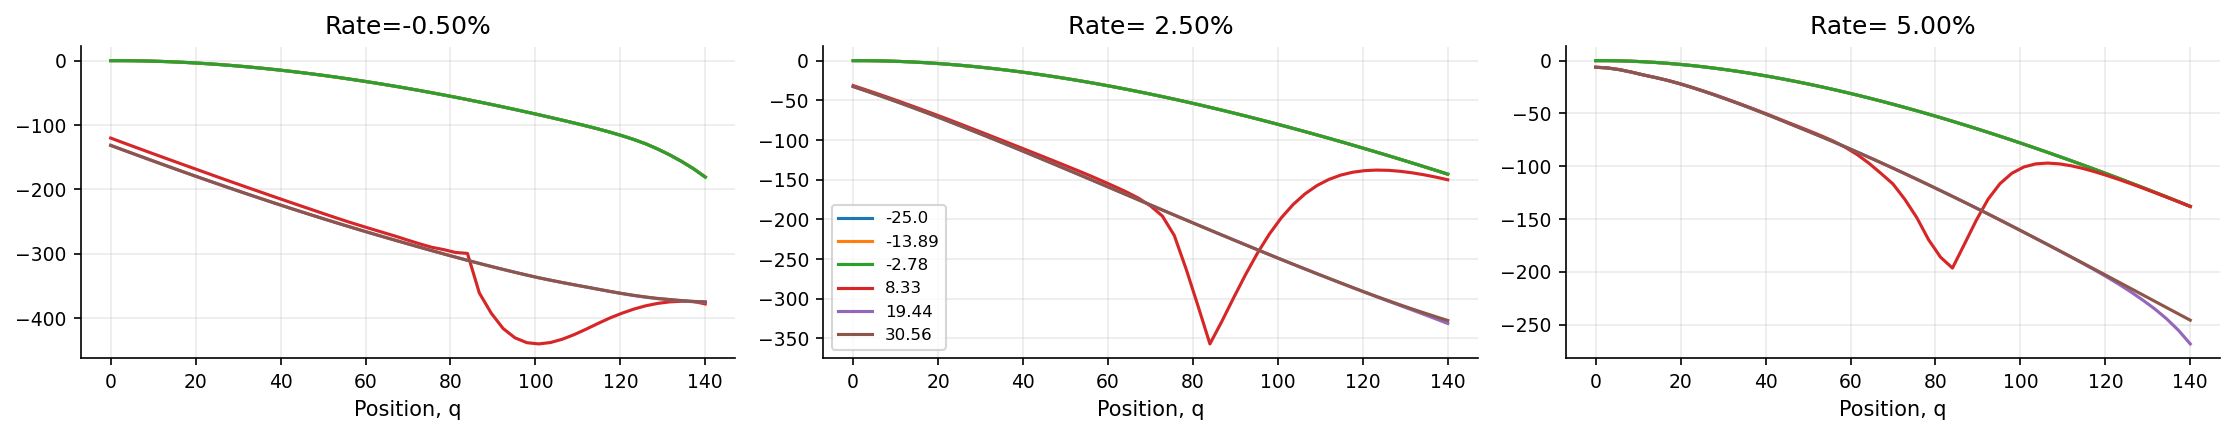

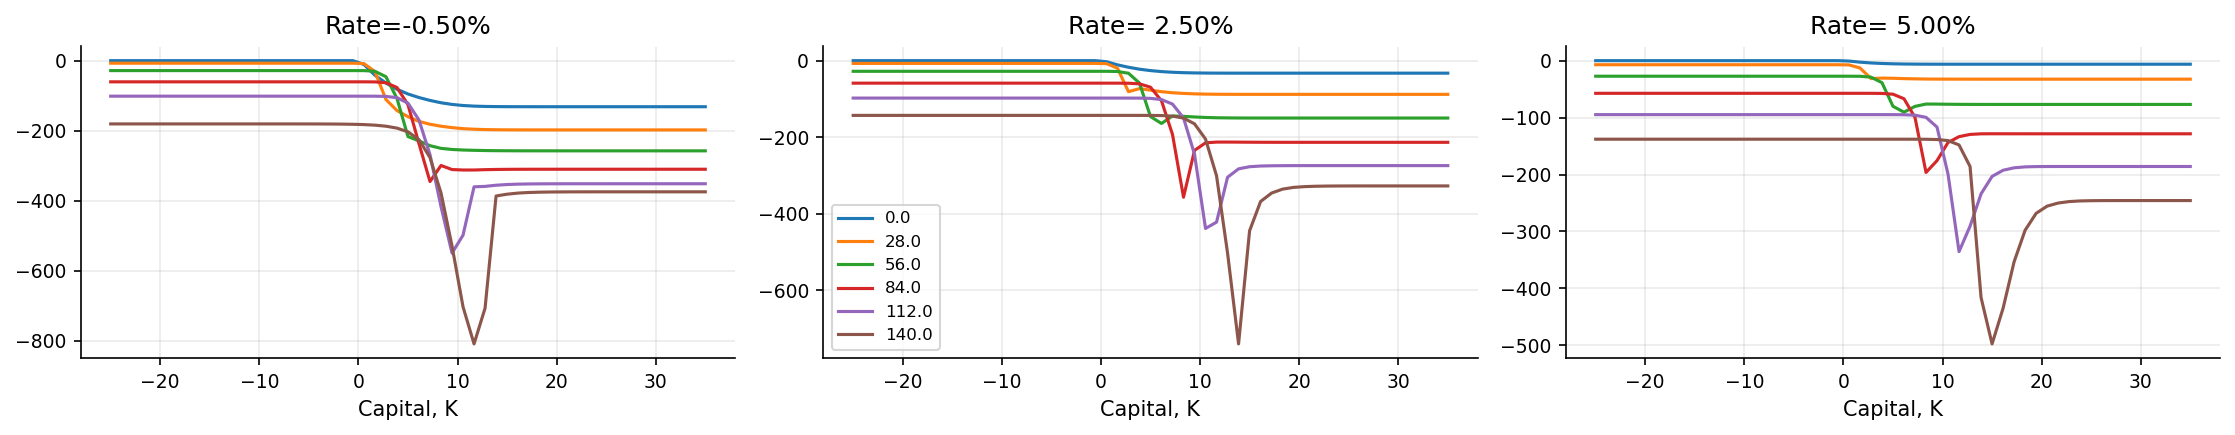

In [177]:
value = deltas['value'][0]
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
for i, rate_index in enumerate([10, 22, 32]):
    ax[i].set_title(f"Rate={100* gpt_model.R_GRID[rate_index] : 0.2f}%")
    ax[i].plot(gpt_model.Q_GRID, value[rate_index, :, ::10])
    ax[i].set_xlabel("Position, q")
ax[1].legend(gpt_model.K_GRID[::10].round(2))
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
for i, rate_index in enumerate([10, 22, 32]):
    ax[i].set_title(f"Rate={100* gpt_model.R_GRID[rate_index] : 0.2f}%")
    ax[i].plot(gpt_model.K_GRID, value[rate_index,  ::10].T)
    ax[i].set_xlabel("Capital, K")
ax[1].legend(gpt_model.Q_GRID[::10].round(2))
fig.tight_layout()
plt.show()